In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from syssimx_examples.controlled_pendulum.components import (
    FMUPendulum, OpenSimPendulum, FEMPendulum
)
from demos.ControlledPendulum.scripts.torque_profiles import (
    constant_torque, ramp_torque, zero_torque
)

from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

from syssimx import Connection, System, FMUComponent
from syssimx.system.connection import EventConnection
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

In [2]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3) # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1.5
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e9

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

In [ ]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [8]:
t = 0.0
while t < t_end:
    # 1) Integrate one time step
    pendulum.do_step(t, dt)

    # 2) Advance time
    t += dt

In [9]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict["alpha"]
    omega_vals[mode] = res_dict["omega"]
    q_vals[mode] = res_dict["theta"]

In [10]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "FEM",
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "OpenSim",
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "EQB",
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

fig_size = (9, 9)
y_suptitle = 1.04
y_subtitle = 1
y_legend = 0.99
top_adjust = 0.9

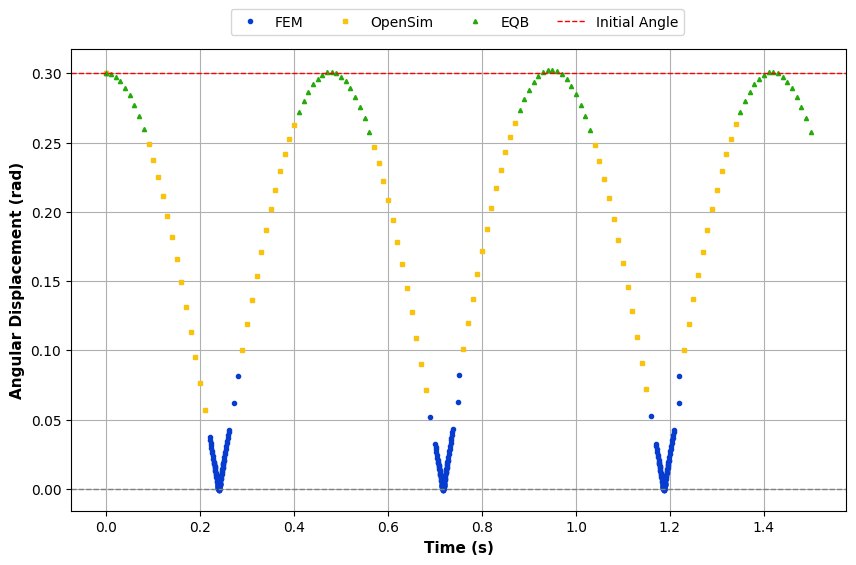

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals["FEM"], q_vals["FEM"], **fem_style)
plt.plot(t_vals["OpenSim"], q_vals["OpenSim"], **opensim_style)
plt.plot(t_vals["FMU"], q_vals["FMU"], **eqb_style)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(q0, color="red", linestyle="--", linewidth=1, label="Initial Angle")
plt.xlabel("Time (s)", fontdict=fontdict)
plt.ylabel("Angular Displacement (rad)", fontdict=fontdict)
plt.legend(bbox_to_anchor=(0.8, 1.1), ncol=4, fontsize=10)
plt.grid()